### 0. Importing PyTorch and setting device-agnostic code 

In [4]:
import torch
from torch import nn

In [5]:
# Setup device-agnostic code 
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### 1. Get data

In [6]:
from pathlib import Path

In [7]:
data_dir = Path("chest_xray")

In [8]:
train_dir = data_dir / "train"
test_dir = data_dir / "test"
val_dir = data_dir / "val"

print(train_dir)
print(test_dir)
print(val_dir)

chest_xray\train
chest_xray\test
chest_xray\val


### 1.1 Visualizing an image

1. Get all of the image paths
2. Pick a random image using Python's random.choice()
3. Get image class using pathlib.Path.parent.stem
4. Since, I am working with images, let's open the image with Python's PIL
5. I'll then show the image and print metadata

In [9]:
import random
from PIL import Image

Image class: NORMAL
Image height: 1333
Image width: 1856


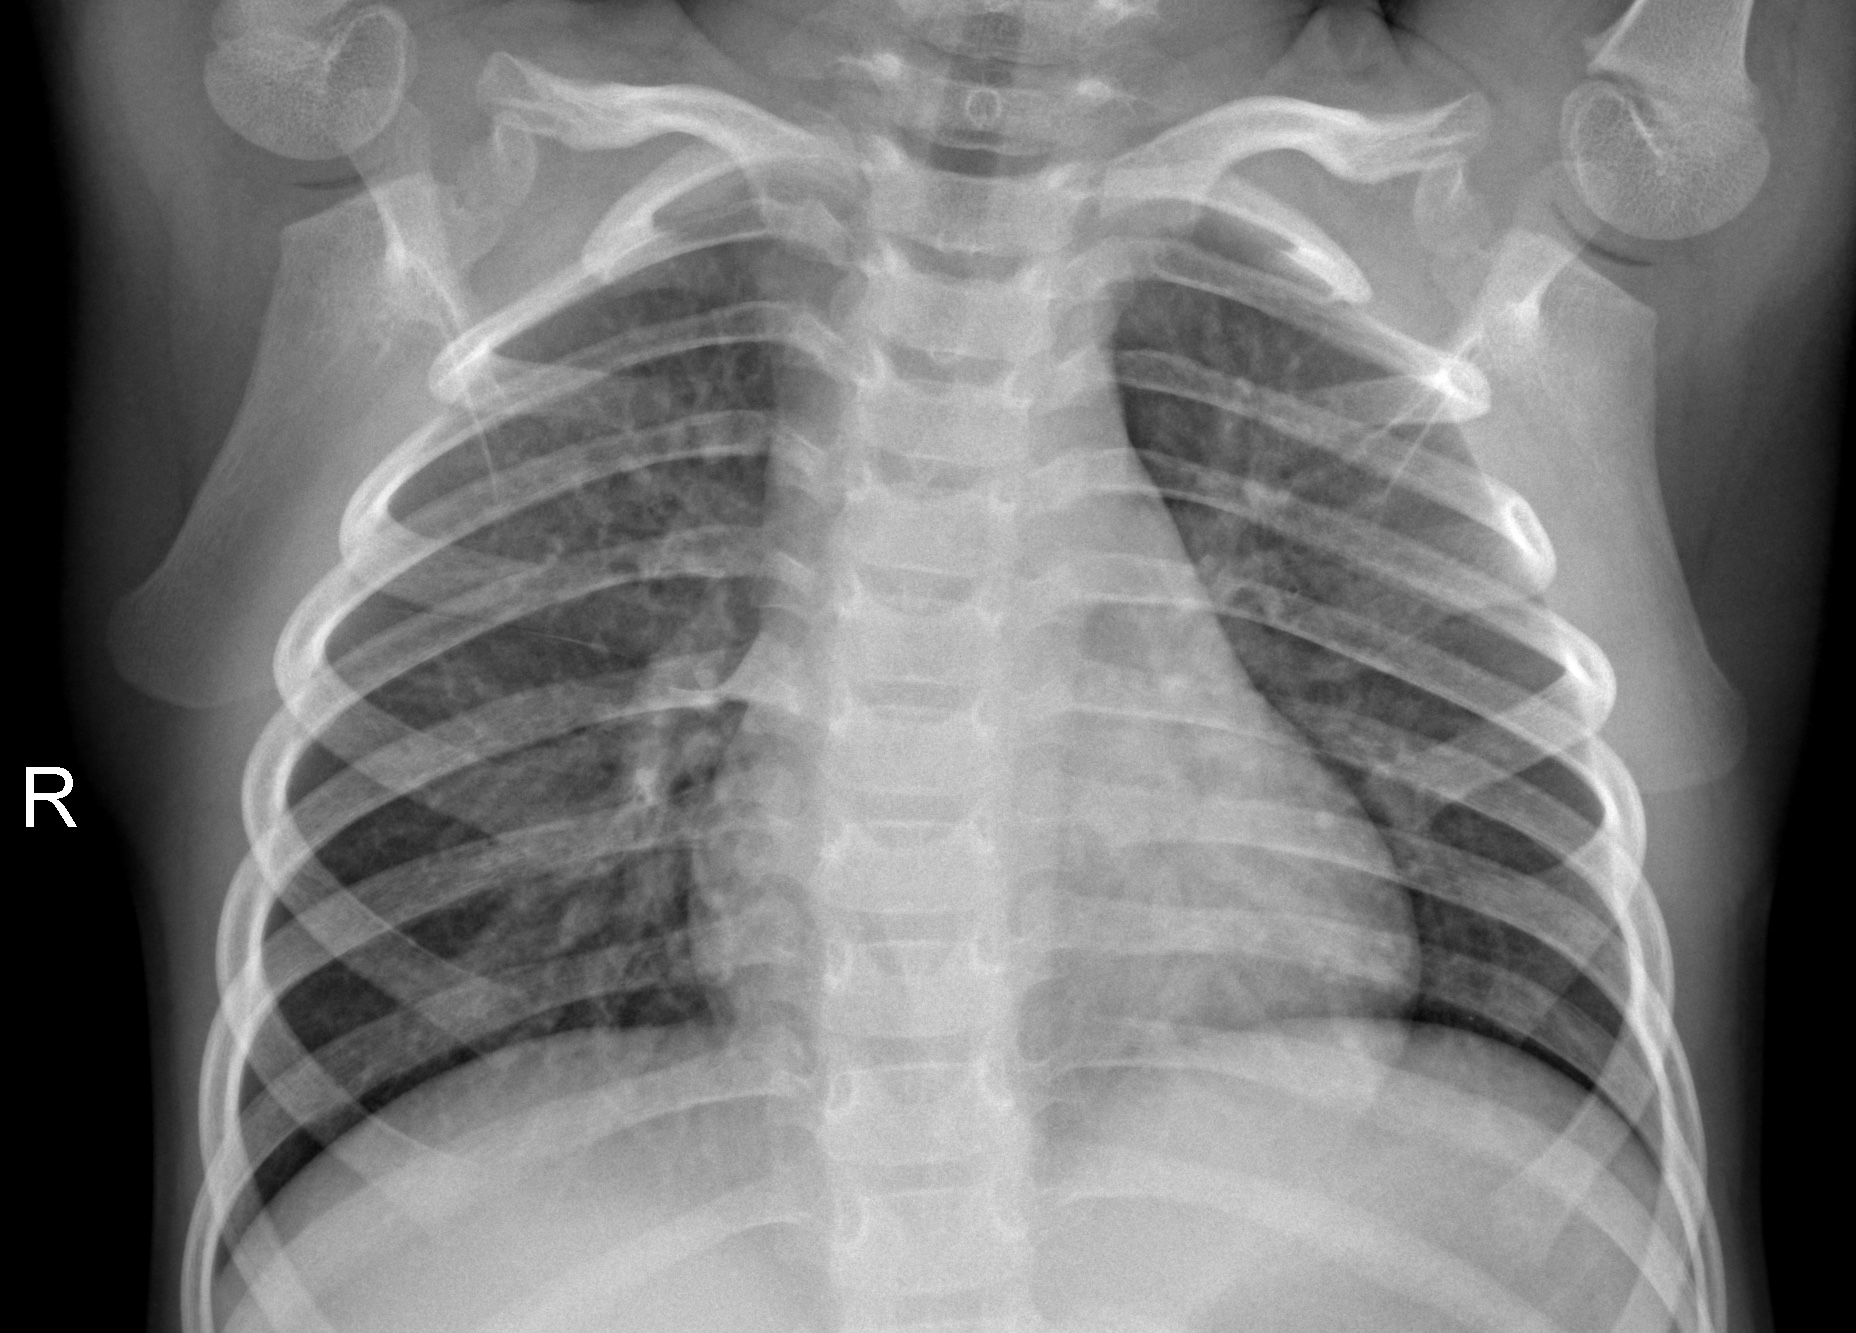

In [10]:
# 1. Getting all the image path 
image_path_list = list(data_dir.glob("*/*/*.jpeg"))
image_path_list

# 2. Pick a random image
random_image_path = random.choice(image_path_list)

# 3. Get the image class from path name(the image class is the name of the directory where the the image is saved)
image_class = random_image_path.parent.stem

# 4. Open the image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

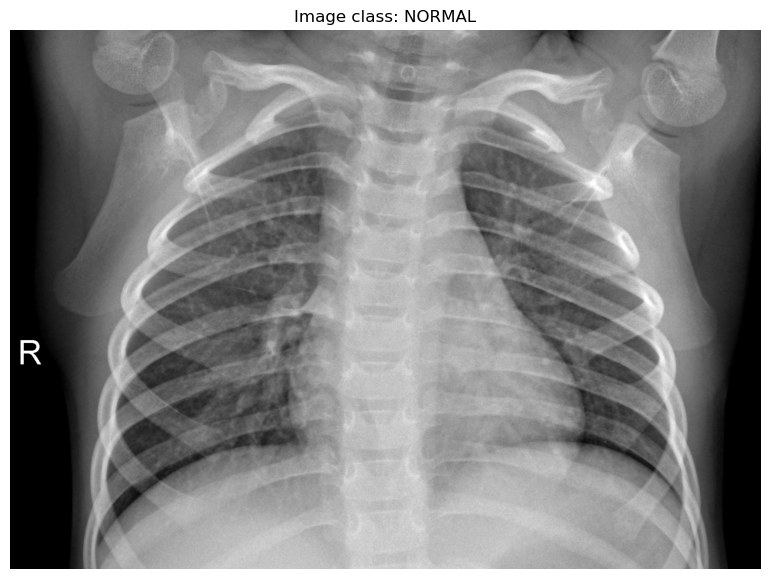

In [11]:
# Visualize with matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Truning image into nparray
img_as_array = np.array(img)

# Plot the image with matplotlib
plt.figure(figsize=(10,7))
plt.imshow(img_as_array, cmap= "gray")
plt.title(f"Image class: {image_class}")
plt.axis(False)
plt.show()


### 2. Making data ready

#### 2.1 Cheking the train and validation split

In [12]:
for split in [train_dir, test_dir, val_dir]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = split / cls
        n = len(list(folder.glob("*.jpeg")))
        print(split.name, cls, n)

train NORMAL 1341
train PNEUMONIA 3875
test NORMAL 234
test PNEUMONIA 390
val NORMAL 8
val PNEUMONIA 8


#### 2.2 Creating new train and validation split (85% and 15%)

In [82]:
import shutil
import random 
import re
from collections import defaultdict

new_val_dir = Path("chest_xray/new_val")
new_train_dir = Path("chest_xray/new_train")

val_fraction = 0.15 # train and validation split is 85-15

def patient_id(fname: str, cls: str) -> str:
    """
    Extracts a patient identifier from the filename so all images
    from the same patient stay on the same side of the split 
    """

    if cls == "PNEUMONIA":
        match = re.match(r"(person\d+)_", fname)
    else:
        match = re.match(r"(IM-\d+)-", fname)
    return match.group(1) if match else fname

for cls in ["NORMAL", "PNEUMONIA"]:
    src_folder = train_dir / cls
    images = list(src_folder.glob("*.jpeg"))

     # Group images by patient so a patient's images never get split across train/val
    by_patient = defaultdict(list)

    for img in images:
        by_patient[patient_id(img.name, cls)].append(img)

    patients = list(by_patient.keys())
    random.shuffle(patients)

    n_val_patients = int(len(patients) * val_fraction)
    val_patients = set(patients[:n_val_patients])

    val_images = [img for pid in val_patients for img in by_patient[pid]]
    train_images = [img for pid in patients if pid not in val_patients for img in by_patient[pid]]

    (new_val_dir / cls).mkdir(parents=True, exist_ok=True)
    (new_train_dir / cls).mkdir(parents=True, exist_ok=True)


    for img in val_images:
        shutil.copy(img, new_val_dir / cls / img.name)
    for img in train_images:
        shutil.copy(img, new_train_dir / cls / img.name)

    print(cls, "| patients train:", len(patients) - len(val_patients), "val:", len(val_patients),
          "| images train:", len(train_images), "val:", len(val_images))



NORMAL | patients train: 1073 val: 189 | images train: 1137 val: 204
PNEUMONIA | patients train: 1390 val: 245 | images train: 3269 val: 606


### 3. Transforming data

Before I can use our image data with PyTorch:

    1. I need to turn my data into tensors.
    2. Turn into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`. 

In [20]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

#### 3.1 Transforming data with `torchvision.transfor`

In [21]:
# transform for images
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size = (64,64)),
    transforms.ToTensor()
])

#### 3.2 plotting different images after transform

In [22]:
def plot_transformed_images(image_path: list, transform, n= 3):
    """
    Selects random images from a path of images and transforms them
    then plots the original vs transformed version.
    """
    random_image_path = random.sample(image_path, k = n)
    for image_path in random_image_path:
        with Image.open(image_path) as f:
            # Plotting Original Images
            fig, ax = plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f, cmap = "gray")
            ax[0].set_title(f"Originl\nSize: {f.size}")
            ax[0].axis(False)

            # Plotting Main Images
            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image, cmap = "gray")
            ax[1].set_title(f"Transformed\nSize: {transformed_image.shape}")
            ax[1].axis(False)

            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize = 16)



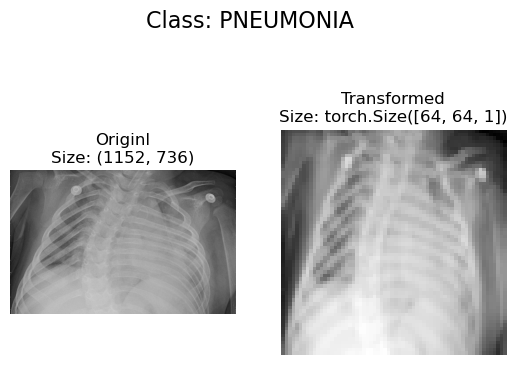

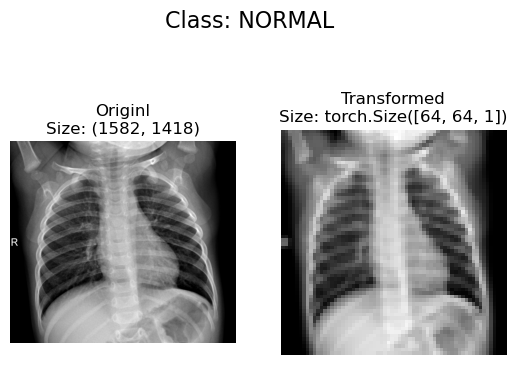

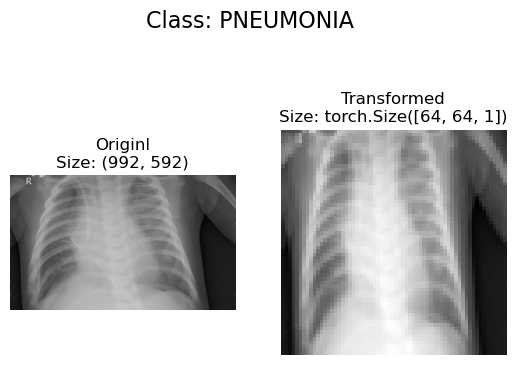

In [23]:
plot_transformed_images(image_path= image_path_list,
                        transform= data_transform,
                        n = 3)

### 4. Loading images using `ImageFolder`

I will be loading the image classification data using `torchvision.datasets.ImageFolder`

In [24]:
from torchvision import datasets
train_data = datasets.ImageFolder(root= new_train_dir,
                                  transform= data_transform,
                                  target_transform= None)
validation_data = datasets.ImageFolder(root = new_val_dir,
                                       transform= data_transform,
                                       target_transform= None)

test_data = datasets.ImageFolder(root = test_dir,
                                 transform= data_transform)

In [25]:
train_data, test_data, validation_data

(Dataset ImageFolder
     Number of datapoints: 4499
     Root location: chesy_xray\new_train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 624
     Root location: chest_xray\test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 717
     Root location: chest_xray\new_val
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [26]:
# Get the class names 
class_names = train_data.classes
class_names

['NORMAL', 'PNEUMONIA']

In [27]:
# Get the class names as dict
class_dict = train_data.class_to_idx
class_dict

{'NORMAL': 0, 'PNEUMONIA': 1}

In [28]:
# checking the length of train and validation 
len(train_data), len(validation_data)

(4499, 717)

#### 4.1 Turning my loaded images into `DataLoader`s

A DataLoader is going to help my dataset into iterables and we can customise the `batch_size` so my model can see the `batch_size` images at a time.

In [29]:
import os 


In [30]:
# Turn train and test datasets into DataLoader'
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKER = os.cpu_count()

train_dataloader = DataLoader(dataset= train_data,
                              batch_size= BATCH_SIZE,
                              num_workers= NUM_WORKER,
                              shuffle= True)
validation_dataloader = DataLoader(dataset= validation_data,
                                   batch_size= BATCH_SIZE,
                                   num_workers= NUM_WORKER,
                                   shuffle= False)
test_dataloader = DataLoader(dataset= test_data,
                             batch_size= BATCH_SIZE,
                             num_workers= NUM_WORKER,
                             shuffle= False)

In [31]:
len(train_dataloader), len(validation_dataloader), len(test_dataloader)

(141, 23, 20)

In [32]:
img , label = next(iter(train_dataloader))
print(f"Image shape: {img.shape}")
print(f"Label shape: {label.shape}")

Image shape: torch.Size([32, 3, 64, 64])
Label shape: torch.Size([32])


### 5. Mode 0 : TinyVGG model

Replicating TinyVGG architecture from CNN Explainer website 

#### 5.1 Creating TinyVGG model class

In [33]:
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from CNN Explainer.
    """
    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int) -> None:
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels= input_shape,
                      out_channels= hidden_units,
                      kernel_size= 3,
                      padding= 0,
                      stride = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_units,
                      out_channels= hidden_units,
                      kernel_size= 3,
                      padding= 0,
                      stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2,
                         stride= 2)             
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels= hidden_units,
                      out_channels= hidden_units,
                      kernel_size= 3,
                      padding= 0,
                      stride = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels= hidden_units,
                                  out_channels= hidden_units,
                                  kernel_size= 3,
                                  padding= 0,
                                  stride = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size= 2,
                         stride = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features= hidden_units * 13* 13,
                      out_features= output_shape)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        #print(x.shape)
        x = self.conv_block2(x)
        #print(x.shape)
        x = self.classifier(x)
        return x

In [34]:
model_0 = TinyVGG(input_shape= 3,
                  hidden_units= 10,
                  output_shape= len(class_names))
model_0

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=2, bias=True)
  )
)

#### 5.2 Try a forward pass on a sing image (to test the model)

In [35]:
img.shape

torch.Size([32, 3, 64, 64])

In [36]:
# Get a single image
model_0(img)

tensor([[-0.0027,  0.0063],
        [-0.0026,  0.0062],
        [-0.0027,  0.0061],
        [-0.0028,  0.0062],
        [-0.0028,  0.0061],
        [-0.0027,  0.0061],
        [-0.0028,  0.0061],
        [-0.0027,  0.0062],
        [-0.0028,  0.0060],
        [-0.0026,  0.0061],
        [-0.0028,  0.0059],
        [-0.0026,  0.0061],
        [-0.0027,  0.0060],
        [-0.0027,  0.0060],
        [-0.0026,  0.0063],
        [-0.0028,  0.0061],
        [-0.0024,  0.0062],
        [-0.0027,  0.0059],
        [-0.0027,  0.0061],
        [-0.0026,  0.0060],
        [-0.0027,  0.0059],
        [-0.0028,  0.0061],
        [-0.0027,  0.0060],
        [-0.0027,  0.0060],
        [-0.0028,  0.0061],
        [-0.0028,  0.0061],
        [-0.0029,  0.0060],
        [-0.0026,  0.0062],
        [-0.0028,  0.0060],
        [-0.0027,  0.0061],
        [-0.0028,  0.0061],
        [-0.0028,  0.0061]], grad_fn=<AddmmBackward0>)

#### 5.3 Use `torch.info` to get an idea of the shapes going through our model

In [37]:
from torchinfo import summary

In [38]:
summary(model_0, input_size= [32,3,64,64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 2]                   --
├─Sequential: 1-1                        [32, 10, 30, 30]          --
│    └─Conv2d: 2-1                       [32, 10, 62, 62]          280
│    └─ReLU: 2-2                         [32, 10, 62, 62]          --
│    └─Conv2d: 2-3                       [32, 10, 60, 60]          910
│    └─ReLU: 2-4                         [32, 10, 60, 60]          --
│    └─MaxPool2d: 2-5                    [32, 10, 30, 30]          --
├─Sequential: 1-2                        [32, 10, 13, 13]          --
│    └─Conv2d: 2-6                       [32, 10, 28, 28]          910
│    └─ReLU: 2-7                         [32, 10, 28, 28]          --
│    └─Conv2d: 2-8                       [32, 10, 26, 26]          910
│    └─ReLU: 2-9                         [32, 10, 26, 26]          --
│    └─MaxPool2d: 2-10                   [32, 10, 13, 13]          --
├─Sequentia

#### 5.4 Creating train and test steps funtions 
* `train_step()` - takes a model and dataloader and trains the model on the DataLoader
* `test_step()` - takes a model and dataloader and test the model on the DataLoader

In [39]:
# Create train_step()

def train_step(model: torch.nn.Module,
               dataloder: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    model.train()
    train_loss, train_acc = 0,0
    # loop through the data batches
    for batch, (X,y) in enumerate(dataloder):
        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate the loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero frad
        optimizer.zero_grad()

        # 4. Loss backward 
        loss.backward()

        # 5. Optimizer step 
        optimizer.step()

        # Calculate accuracy metric
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)
    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloder)
    train_acc = train_acc / len(dataloder)
    return train_loss, train_acc 

In [40]:
# Create eval step

def eval_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):

    # Put the model in eval mode
    model.eval()

    # Setup loss and accuracy values
    loss_total, acc_total = 0,0

    # Turn on inference mode 
    with torch.inference_mode():
        for batch, (X,y) in enumerate(dataloader):
            # 1. Forward pass 
            test_pred_logits = model(X)

            # 2. Calculate the loss
            loss = loss_fn(test_pred_logits, y)
            loss_total += loss.item()

            # Calculate the accuracy 
            test_pred_labels = test_pred_logits.argmax(dim = 1)
            acc_total += ((test_pred_labels == y).sum().item()/ len(test_pred_labels))

    loss_total = loss_total / len(dataloader)
    acc_total = acc_total / len(dataloader)
    return loss_total, acc_total



#### 5.5 Creating `train()` funtion to combine `train_step()` and `eval_step()`

In [41]:
from tqdm.auto import tqdm

# 1. Create a train funtion that takes in various model parameters + optimizer + dataloaders 

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          val_dataloader: torch.utils.data.DataLoader,
          optimizer : torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int):
    # 2. Creating result dictionary 
    results = {
        "train_loss" : [],
        "train_acc" : [],
        "val_loss" : [],
        "val_acc" : []
    }
    # 3. Loop through training and eval step
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model = model, 
                                           dataloder= train_dataloader,
                                           loss_fn = loss_fn,
                                           optimizer= optimizer)
        val_loss, val_acc = eval_step(model = model, 
                                      dataloader= val_dataloader,
                                      loss_fn= loss_fn)

        # 4. Print out what's happening
        print(f"Epoch : {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}% | Validation loss: {val_loss:.4f} | Validation acc: {val_acc:.4f}%")

        # 5. Update results dictionary 
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    return results

        

#### 5.6 Train and evaluate `model_0`

In [42]:
NUM_EPOCHS = 5

# Setup the loss funtion and optimizer 

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params= model_0.parameters(), lr = 0.001)

# Train the model_0
model_0_results = train(model = model_0,
                        train_dataloader= train_dataloader,
                        val_dataloader= validation_dataloader,
                        optimizer= optimizer,
                        loss_fn= loss_fn,
                        epochs= NUM_EPOCHS)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 | Train loss: 0.5775 | Train acc: 0.7472% | Validation loss: 0.5926 | Validation acc: 0.7228%
Epoch : 1 | Train loss: 0.5487 | Train acc: 0.7532% | Validation loss: 0.4516 | Validation acc: 0.8126%
Epoch : 2 | Train loss: 0.2608 | Train acc: 0.8907% | Validation loss: 0.1765 | Validation acc: 0.9307%
Epoch : 3 | Train loss: 0.1750 | Train acc: 0.9326% | Validation loss: 0.1537 | Validation acc: 0.9375%
Epoch : 4 | Train loss: 0.1612 | Train acc: 0.9377% | Validation loss: 0.1349 | Validation acc: 0.9511%


In [43]:
test_loss, test_acc = eval_step(model=model_0,
                                 dataloader=test_dataloader,
                                 loss_fn=loss_fn,
                                 )
print(f"Final Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

Final Test loss: 0.8409 | Test acc: 0.7406


#### 5.7 Plotting the loss curves for `model_0`

 A loss curve is a way of tracking my model's progression over time.

In [44]:
# Get the model_0 results key

model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'val_loss', 'val_acc'])

In [45]:
def plot_loss_curves(results: dict[str, list[float]]):
    """Plots training and validation curves of the result dictionary"""
    train_loss = results["train_loss"]
    val_loss = results["val_loss"]

    train_acc = results["train_acc"]
    val_acc = results["val_acc"]

    # How many epochs there are 
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))

    # Plot both loss
    plt.subplot(1,2,1)
    plt.plot(epochs, train_loss, label = "Train Loss")
    plt.plot(epochs, val_loss, label = "Validation Loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot both accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, train_acc, label = "Train Accuracy")
    plt.plot(epochs, val_acc, label = "Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend() 

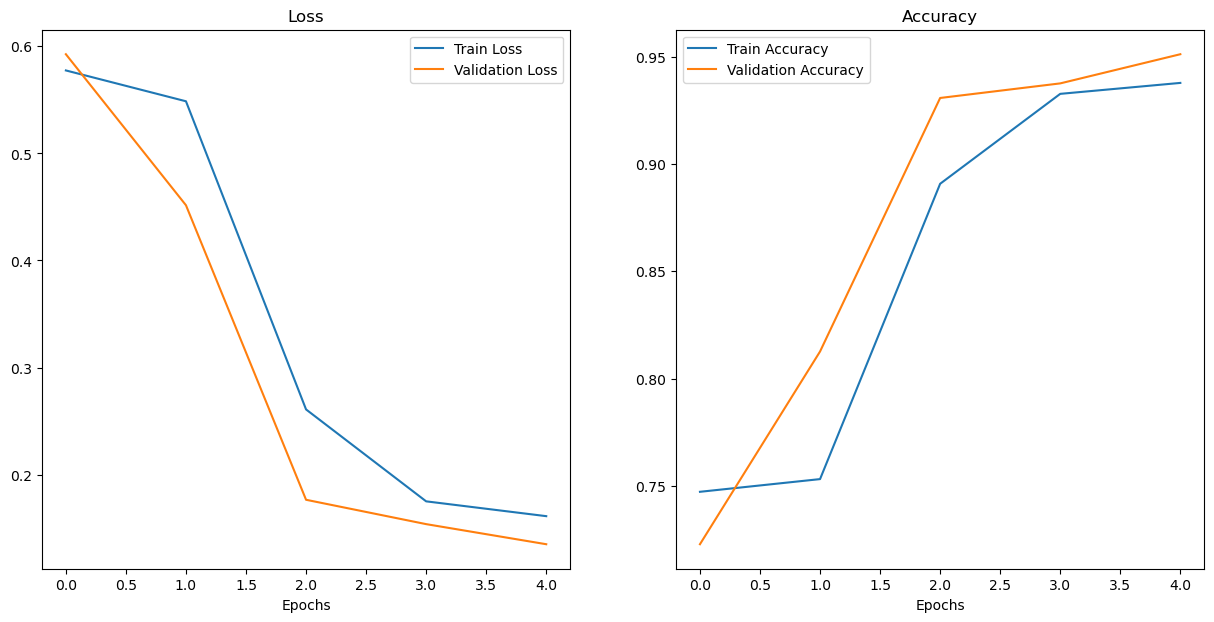

In [46]:
plot_loss_curves(results=model_0_results)

#### 5.8 Evaluating the model using other metrics

In [47]:
from sklearn.metrics import classification_report, confusion_matrix

model_0.eval()
all_preds = []
all_labels = []

with torch.inference_mode():
    for X,y in test_dataloader:
        logits = model_0(X)
        preds = logits.argmax(dim = 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

[[ 74 160]
 [  6 384]]
              precision    recall  f1-score   support

      NORMAL       0.93      0.32      0.47       234
   PNEUMONIA       0.71      0.98      0.82       390

    accuracy                           0.73       624
   macro avg       0.82      0.65      0.65       624
weighted avg       0.79      0.73      0.69       624



### 6. Experiments (Class weights)

Penalize mistakes on the minority class (NORMAL) more heavily than mistakes on the majority class.

In [48]:
normal_count = len(os.listdir(new_train_dir / "NORMAL"))
pneumonia_count = len(os.listdir(new_train_dir / "PNEUMONIA"))
print(f"NORMAL: {normal_count}, PNEUMONIA: {pneumonia_count}")

NORMAL: 1137, PNEUMONIA: 3362


In [49]:
total = normal_count + pneumonia_count

# Inverse frequency weighting

weight_normal = total / (2*normal_count)
weight_pneumonia = total / (2*pneumonia_count)

print(f"Noraml weight: {weight_normal}")
print(f"Pneumonia weight: {weight_pneumonia}")

Noraml weight: 1.9784520668425682
Pneumonia weight: 0.6690957763236169


In [50]:
class_weights = torch.tensor([weight_normal, weight_pneumonia], dtype = torch.float32)
print(class_weights)

loss_fn_weighted = nn.CrossEntropyLoss(weight=class_weights)


tensor([1.9785, 0.6691])


#### 6.1 model_1

New model instance is model_1 is for the changed weights

In [51]:
model_1 = TinyVGG(input_shape= 3,
                  hidden_units= 10,
                  output_shape= len(class_names))
model_1

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=2, bias=True)
  )
)

In [52]:
# New optimizer created
optimizer_1 = torch.optim.Adam(params = model_1.parameters(), lr = 0.001)

In [53]:
model_1_results = train(model= model_1,
                        train_dataloader= train_dataloader,
                        val_dataloader= validation_dataloader,
                        optimizer= optimizer_1,
                        loss_fn= loss_fn_weighted,
                        epochs= NUM_EPOCHS)


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 | Train loss: 0.4894 | Train acc: 0.7732% | Validation loss: 0.5512 | Validation acc: 0.7218%
Epoch : 1 | Train loss: 0.2201 | Train acc: 0.9139% | Validation loss: 0.1764 | Validation acc: 0.9321%
Epoch : 2 | Train loss: 0.1653 | Train acc: 0.9340% | Validation loss: 0.1261 | Validation acc: 0.9470%
Epoch : 3 | Train loss: 0.1578 | Train acc: 0.9410% | Validation loss: 0.1147 | Validation acc: 0.9592%
Epoch : 4 | Train loss: 0.1428 | Train acc: 0.9511% | Validation loss: 0.1100 | Validation acc: 0.9565%


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

model_1.eval()
all_preds_1 = []
all_labels_1 = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = model_1(X)
        preds = logits.argmax(dim=1)
        all_preds_1.extend(preds.cpu().numpy())
        all_labels_1.extend(y.cpu().numpy())

print(confusion_matrix(all_labels_1, all_preds_1))
print(classification_report(all_labels_1, all_preds_1, target_names=class_names))

[[ 81 153]
 [ 10 380]]
              precision    recall  f1-score   support

      NORMAL       0.89      0.35      0.50       234
   PNEUMONIA       0.71      0.97      0.82       390

    accuracy                           0.74       624
   macro avg       0.80      0.66      0.66       624
weighted avg       0.78      0.74      0.70       624



### 7. Saving both the baseline models

In [55]:
os.makedirs("checkpoints", exist_ok = True)

torch.save(model_0.state_dict(), "checkpoints/tinyvgg_baseline.pth")
torch.save(model_1.state_dict(), "checkpoints/tinyvgg_weighted_loss.pth")

In [56]:
model_0 = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names)).to(device)
model_0.load_state_dict(torch.load("checkpoints/tinyvgg_baseline.pth"))
model_0.eval()  # if you're just doing inference, not continuing training

TinyVGG(
  (conv_block1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=2, bias=True)
  )
)

### 8. Data processing for Pretrained Model(ResNet)

#### 8.l Transforming images for ResNet

In [57]:

data_transform1 = transforms.Compose([
    # Resize our images to 224x224
    transforms.Resize(size = (224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

#### 8.2 Loading images Using ImageFolder (ResNet)

In [58]:
from torchvision import datasets
new_train_data = datasets.ImageFolder(root= new_train_dir,
                                  transform= data_transform1,
                                  target_transform= None)
new_validation_data = datasets.ImageFolder(root = new_val_dir,
                                       transform= data_transform1,
                                       target_transform= None)

new_test_data = datasets.ImageFolder(root = test_dir,
                                 transform= data_transform1)

In [59]:
# Get the class names 
class_names = new_train_data.classes
class_names

['NORMAL', 'PNEUMONIA']

In [60]:
# Get the class names as dict
class_dict = new_train_data.class_to_idx
class_dict

{'NORMAL': 0, 'PNEUMONIA': 1}

#### 8.3 Turning loaded images into DataLoader for ResNet

In [61]:
# Turn train and test datasets into DataLoader'
import os 
from torch.utils.data import DataLoader
BATCH_SIZE = 32
NUM_WORKER = os.cpu_count()

new_train_dataloader = DataLoader(dataset= new_train_data,
                              batch_size= BATCH_SIZE,
                              num_workers= NUM_WORKER,
                              shuffle= True)
new_validation_dataloader = DataLoader(dataset= new_validation_data,
                                   batch_size= BATCH_SIZE,
                                   num_workers= NUM_WORKER,
                                   shuffle= False)
new_test_dataloader = DataLoader(dataset= new_test_data,
                             batch_size= BATCH_SIZE,
                             num_workers= NUM_WORKER,
                             shuffle= False)

#### 8.4 Checking the new data


In [62]:
print(new_train_data.classes, new_train_data.class_to_idx)

X, y = next(iter(new_train_dataloader))
print(X.shape, y.shape)

['NORMAL', 'PNEUMONIA'] {'NORMAL': 0, 'PNEUMONIA': 1}
torch.Size([32, 3, 224, 224]) torch.Size([32])


In [63]:
new_train_files = {p.name for cls in ["NORMAL", "PNEUMONIA"] for p in (new_train_dir / cls).glob("*.jpeg")}
new_val_files = {p.name for cls in ["NORMAL", "PNEUMONIA"] for p in (new_val_dir / cls).glob("*.jpeg")}

print("Duplicate filenames in both sets:", len(new_train_files & new_val_files))

for cls in ["NORMAL", "PNEUMONIA"]:
    train_ids = {patient_id(p.name, cls) for p in (new_train_dir / cls).glob("*.jpeg")}
    val_ids = {patient_id(p.name, cls) for p in (new_val_dir / cls).glob("*.jpeg")}
    print(cls, "| patient overlap:", len(train_ids & val_ids))


Duplicate filenames in both sets: 0
NORMAL | patient overlap: 0
PNEUMONIA | patient overlap: 0


### 9. ResNet

#### 9.1 Importing the model

In [64]:
import torchvision.models as models

weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights = weights)

In [65]:
print(resnet.fc)

Linear(in_features=512, out_features=1000, bias=True)


#### 9.2 Freezing the backbone and replacing the final layer with my 2-class problem

In [66]:
for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Linear(in_features= 512,
                      out_features= len(class_names))

In [67]:
for name, param in resnet.named_parameters():
    if param.requires_grad:
        print(name, param.requires_grad)

fc.weight True
fc.bias True


#### 9.3 Optimizer and resuing the train funtion 

In [68]:
optimzer_resnet = torch.optim.Adam(params= resnet.parameters(), lr = 0.001)

resnet_result = train(model = resnet,
                      train_dataloader= new_train_dataloader,
                      val_dataloader= new_validation_dataloader,
                      optimizer= optimzer_resnet,
                      loss_fn= loss_fn_weighted,
                      epochs= 5)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 0 | Train loss: 0.2983 | Train acc: 0.8769% | Validation loss: 0.1804 | Validation acc: 0.9355%
Epoch : 1 | Train loss: 0.1983 | Train acc: 0.9278% | Validation loss: 0.1587 | Validation acc: 0.9458%
Epoch : 2 | Train loss: 0.1623 | Train acc: 0.9379% | Validation loss: 0.1467 | Validation acc: 0.9526%
Epoch : 3 | Train loss: 0.1505 | Train acc: 0.9439% | Validation loss: 0.1336 | Validation acc: 0.9518%
Epoch : 4 | Train loss: 0.1428 | Train acc: 0.9497% | Validation loss: 0.1927 | Validation acc: 0.9322%


#### 9.4 ResNet's Performance

In [69]:


from sklearn.metrics import classification_report, confusion_matrix

resnet.eval()
all_preds_2 = []
all_labels_2 = []

with torch.inference_mode():
    for X, y in new_test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = resnet(X)
        preds = logits.argmax(dim=1)
        all_preds_2.extend(preds.cpu().numpy())
        all_labels_2.extend(y.cpu().numpy())

print(confusion_matrix(all_labels_2, all_preds_2))
print(classification_report(all_labels_2, all_preds_2, target_names=class_names))

[[186  48]
 [ 23 367]]
              precision    recall  f1-score   support

      NORMAL       0.89      0.79      0.84       234
   PNEUMONIA       0.88      0.94      0.91       390

    accuracy                           0.89       624
   macro avg       0.89      0.87      0.88       624
weighted avg       0.89      0.89      0.88       624



In [70]:
torch.save(resnet.state_dict(), "checkpoints/resnet18_frozen.pth")


### 9.5 Changing ResNet18 inner things 

In [71]:
# New instance for the new model
resnet_unfrozen = models.resnet18(weights= weights)

In [72]:
# Freeze everything , then unfreeze layer 4 + output layer 
for param in resnet_unfrozen.parameters():
    param.requires_grad = False#

resnet_unfrozen.fc = nn.Linear(in_features= 512, out_features= len(class_names))

for name, param in resnet_unfrozen.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# Confirming what's trainable
for name, param in resnet_unfrozen.named_parameters():
    if param.requires_grad:
        print(name, param.requires_grad)
    

layer4.0.conv1.weight True
layer4.0.bn1.weight True
layer4.0.bn1.bias True
layer4.0.conv2.weight True
layer4.0.bn2.weight True
layer4.0.bn2.bias True
layer4.0.downsample.0.weight True
layer4.0.downsample.1.weight True
layer4.0.downsample.1.bias True
layer4.1.conv1.weight True
layer4.1.bn1.weight True
layer4.1.bn1.bias True
layer4.1.conv2.weight True
layer4.1.bn2.weight True
layer4.1.bn2.bias True
fc.weight True
fc.bias True


#### 9.6 ResNet18(layer 4 + fc layer unfozen training) 

In [73]:
# Discriminative learning rates 
optimizer_unfrozen = torch.optim.Adam([{"params": resnet_unfrozen.layer4.parameters(), "lr": 1e-4},
                                        {"params": resnet_unfrozen.fc.parameters(), "lr": 1e-3},])

In [ ]:
resnet_unfrozen_results = train(model = resnet_unfrozen,
                                train_dataloader= new_train_dataloader,
                                val_dataloader= new_validation_dataloader,
                                optimizer= optimizer_unfrozen,
                                loss_fn= loss_fn_weighted,
                                epochs= NUM_EPOCHS)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch : 0 | Train loss: 0.1046 | Train acc: 0.9609% | Validation loss: 0.0503 | Validation acc: 0.9838%
Epoch : 1 | Train loss: 0.0178 | Train acc: 0.9946% | Validation loss: 0.0430 | Validation acc: 0.9825%
Epoch : 2 | Train loss: 0.0053 | Train acc: 0.9991% | Validation loss: 0.0605 | Validation acc: 0.9825%
Epoch : 3 | Train loss: 0.0030 | Train acc: 0.9993% | Validation loss: 0.0520 | Validation acc: 0.9838%
Epoch : 4 | Train loss: 0.0088 | Train acc: 0.9971% | Validation loss: 0.0606 | Validation acc: 0.9825%
Epoch : 5 | Train loss: 0.0104 | Train acc: 0.9964% | Validation loss: 0.0704 | Validation acc: 0.9812%
Epoch : 6 | Train loss: 0.0067 | Train acc: 0.9987% | Validation loss: 0.0485 | Validation acc: 0.9800%
Epoch : 7 | Train loss: 0.0118 | Train acc: 0.9964% | Validation loss: 0.0525 | Validation acc: 0.9838%
Epoch : 8 | Train loss: 0.0032 | Train acc: 0.9987% | Validation loss: 0.0513 | Validation acc: 0.9875%
Epoch : 9 | Train loss: 0.0013 | Train acc: 0.9996% | Validation

#### 9.7 ResNet18(layer 4 + fc layer unfozen result) 

In [47]:
resnet.eval()
all_preds_2 = []
all_labels_2 = []

with torch.inference_mode():
    for X, y in new_test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = resnet_unfrozen(X)
        preds = logits.argmax(dim=1)
        all_preds_2.extend(preds.cpu().numpy())
        all_labels_2.extend(y.cpu().numpy())

print(confusion_matrix(all_labels_2, all_preds_2))
print(classification_report(all_labels_2, all_preds_2, target_names=class_names))

[[125 109]
 [  3 387]]
              precision    recall  f1-score   support

      NORMAL       0.98      0.53      0.69       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.88      0.76      0.78       624
weighted avg       0.85      0.82      0.80       624



#### 9.8 ResNet18(layer 4 + fc layer unfozen training dropout added) 

In [ ]:
resnet_unfrozen2 = models.resnet18(weights=weights)

for param in resnet_unfrozen2.parameters():
    param.requires_grad = False

# Dropout before the final linear layer
resnet_unfrozen2.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features=512, out_features=len(class_names))
)

for name, param in resnet_unfrozen2.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True


#### 9.9 Result

In [ ]:
optimizer_unfrozen2 = torch.optim.Adam([
    {"params": resnet_unfrozen2.layer4.parameters(), "lr": 1e-4},
    {"params": resnet_unfrozen2.fc.parameters(), "lr": 1e-3},
])

resnet_unfrozen2_results = train(model=resnet_unfrozen2,
                                  train_dataloader=new_train_dataloader,
                                  val_dataloader=new_validation_dataloader,
                                  optimizer=optimizer_unfrozen2,
                                  loss_fn=loss_fn_weighted,
                                  epochs=NUM_EPOCHS)


  0%|          | 0/8 [00:00<?, ?it/s]

Epoch : 0 | Train loss: 0.1131 | Train acc: 0.9546% | Validation loss: 0.0675 | Validation acc: 0.9800%
Epoch : 1 | Train loss: 0.0345 | Train acc: 0.9886% | Validation loss: 0.0448 | Validation acc: 0.9850%
Epoch : 2 | Train loss: 0.0119 | Train acc: 0.9969% | Validation loss: 0.0548 | Validation acc: 0.9800%
Epoch : 3 | Train loss: 0.0057 | Train acc: 0.9989% | Validation loss: 0.0556 | Validation acc: 0.9862%
Epoch : 4 | Train loss: 0.0026 | Train acc: 0.9998% | Validation loss: 0.0496 | Validation acc: 0.9875%
Epoch : 5 | Train loss: 0.0035 | Train acc: 0.9987% | Validation loss: 0.1122 | Validation acc: 0.9750%
Epoch : 6 | Train loss: 0.0044 | Train acc: 0.9980% | Validation loss: 0.0698 | Validation acc: 0.9800%
Epoch : 7 | Train loss: 0.0088 | Train acc: 0.9971% | Validation loss: 0.0860 | Validation acc: 0.9825%


In [50]:
resnet.eval()
all_preds_2 = []
all_labels_2 = []

with torch.inference_mode():
    for X, y in new_test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = resnet_unfrozen2(X)
        preds = logits.argmax(dim=1)
        all_preds_2.extend(preds.cpu().numpy())
        all_labels_2.extend(y.cpu().numpy())

print(confusion_matrix(all_labels_2, all_preds_2))
print(classification_report(all_labels_2, all_preds_2, target_names=class_names))

[[113 121]
 [  2 388]]
              precision    recall  f1-score   support

      NORMAL       0.98      0.48      0.65       234
   PNEUMONIA       0.76      0.99      0.86       390

    accuracy                           0.80       624
   macro avg       0.87      0.74      0.76       624
weighted avg       0.84      0.80      0.78       624



#### 9.10 ResNet34

In [77]:
weights34 = models.ResNet34_Weights.DEFAULT
resnet34 = models.resnet34(weights=weights34)

for param in resnet34.parameters():
    param.requires_grad = False          # <- freeze everything

resnet34.fc = nn.Linear(in_features=512, out_features=len(class_names))  # <- fc is trainable by default

for name, param in resnet34.named_parameters():
    if param.requires_grad:
        print(name, param.requires_grad)  # <- should only print fc.*


fc.weight True
fc.bias True


In [ ]:
optimzer_resnet34 = torch.optim.Adam(params= resnet34.parameters(), lr = 0.001)

resnet34_results = train(model = resnet34,
                      train_dataloader= new_train_dataloader,
                      val_dataloader= new_validation_dataloader,
                      optimizer= optimzer_resnet34,
                      loss_fn= loss_fn_weighted,
                      epochs= 5)

In [ ]:
resnet34.eval()
all_preds_2 = []
all_labels_2 = []

with torch.inference_mode():
    for X, y in new_test_dataloader:
        X, y = X.to(device), y.to(device)
        logits = resnet34(X)
        preds = logits.argmax(dim=1)
        all_preds_2.extend(preds.cpu().numpy())
        all_labels_2.extend(y.cpu().numpy())

print(confusion_matrix(all_labels_2, all_preds_2))
print(classification_report(all_labels_2, all_preds_2, target_names=class_names))

[[174  60]
 [ 15 375]]
              precision    recall  f1-score   support

      NORMAL       0.92      0.74      0.82       234
   PNEUMONIA       0.86      0.96      0.91       390

    accuracy                           0.88       624
   macro avg       0.89      0.85      0.87       624
weighted avg       0.88      0.88      0.88       624

